# CausalML API: Quick Start

This notebook provides a runnable walkthrough of the `CausalNavigator` API.
Each section pairs the API documentation with a live code cell so you can
test every method end-to-end.

The `CausalML` module is a high-level wrapper around the `causalml` library
designed to simplify causal inference workflows for observational studies. It
includes the `CausalNavigator` class for heterogeneous treatment effect
estimation, diagnostic methods for assumption validation, and helper
functions for data preprocessing and visualisation.

## Architecture

While `causalml` provides powerful meta-learners (S/T/X-Learners), the
native API requires significant boilerplate for data preprocessing,
assumption checking, and visualisation. `CausalNavigator` standardises that
workflow into a single class.

The core pipeline has three layers:

1. **Diagnostic Layer** - Verifies causal assumptions (specifically Common
   Support) before estimation
2. **Estimation Layer** - Wraps `causalml.inference.meta` classes
   (`BaseXRegressor`, etc.) and injects XGBoost as the standard base learner
3. **Interpretation Layer** - Provides built-in methods to visualise
   heterogeneity, abstracting away `matplotlib` complexity

## Setup

Import dependencies and the `CausalNavigator` class from `utils.py`.

In [12]:
%load_ext autoreload
%autoreload 2

import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import helpers.hnotebook as hnotebo
hnotebo.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

Failed to reload module 'utils' from file '/git_root/tutorials/CausalML_Diabetes_Study/utils.py'
Traceback (most recent call last):
  File "/opt/venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/opt/venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/git_root/tutorials/CausalML_Diabetes_Study/utils.py", line 48
    <<<<<<< U

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of utils failed: Traceback (most recent call last):
  File "/opt/venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/opt/venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/git_root/tutorials/CausalML_Diabetes_Study/utils.py", line 48
    <<<<<<< Updated upstream
    ^^
SyntaxError: invalid syntax
]


In [13]:
import os
import warnings

from utils import (
    CausalNavigator,
    download_cdc_data_if_needed,
    load_cdc_data,
    preprocess_for_causal,
)

# Configuration.
warnings.filterwarnings("ignore")

### Load and Preprocess Data

**Function**: `load_cdc_data(filepath)`

- **Purpose**: Robustly loads the CDC dataset from a local directory
- **Behavior**: Checks for file existence, removes duplicates, and casts all columns to `float`
- **Output**: A cleaned `pandas.DataFrame`

**Function**: `preprocess_for_causal(df, ...)`

- **Purpose**: Splits the dataframe into components for causal analysis:
  - **X (Covariates)** - features used to control for confounding
  - **T (Treatment)** - the binary intervention vector
  - **Y (Outcome)** - the target variable

In [14]:
# Download and load the dataset.
filename = "diabetes_binary_health_indicators_BRFSS2015.csv"
data_path = os.path.join("data", "unprocessed", filename)
download_cdc_data_if_needed(data_path)
df_raw = load_cdc_data(data_path)

# Prepare data for causal analysis.
treatment_col = "PhysActivity"
outcome_col = "Diabetes_binary"
covariate_cols = [
    "HighBP",
    "HighChol",
    "Age",
    "Income",
    "Sex",
    "GenHlth",
    "BMI",
]

df_clean, X, T, Y = preprocess_for_causal(
    df_raw,
    treatment_col=treatment_col,
    outcome_col=outcome_col,
    covariate_cols=covariate_cols,
)

INFO:utils:Dataset already present at: data/unprocessed/diabetes_binary_health_indicators_BRFSS2015.csv
INFO:utils:Loading data from: data/unprocessed/diabetes_binary_health_indicators_BRFSS2015.csv
INFO:utils:Dropped 24206 duplicate rows


## Prepare Demo Data

Set seed for reproducibility and subsample for speed.

**Parameters**:

- `learner_type`: Meta-learner to use: `'S'`, `'T'`, or `'X'`
- `control_name`: Label for the untreated group (used in plots)
- `treatment_name`: Label for the treated group (used in plots)

In [15]:
# Set seed for reproducibility and subsample for speed.
np.random.seed(42)
sample_indices = np.random.choice(X.index, size=10000, replace=False)
X_demo = X.loc[sample_indices]
T_demo = T.loc[sample_indices]
Y_demo = Y.loc[sample_indices]
print(f"API Demo Data Loaded. Shape: {X_demo.shape}")
print(X_demo.head())

# Initialize the CausalNavigator.
navigator = CausalNavigator(
    learner_type="X", control_name="Sedentary", treatment_name="Active"
)

API Demo Data Loaded. Shape: (10000, 7)
        HighBP  HighChol   Age  Income  Sex  GenHlth   BMI
218137     0.0       0.0  10.0     8.0  0.0      2.0  24.0
234092     0.0       0.0  13.0     4.0  0.0      1.0  22.0
220499     0.0       0.0  10.0     4.0  1.0      2.0  25.0
133305     1.0       1.0  10.0     1.0  0.0      5.0  24.0
1394       0.0       1.0  12.0     2.0  0.0      3.0  28.0


### `check_overlap(X, T)`

**Purpose**: Validates the Positivity/Overlap assumption.

- **Inputs**: Covariate matrix `X`, Treatment vector `T`
- **Output**: A density plot of Propensity Scores
- **Why use this**: If the distributions do not overlap, causal estimation is
  invalid. This method enforces safety before modelling - the treated and
  control groups must share common support across the feature space.

INFO:utils:Calculating Propensity Scores for Overlap Check


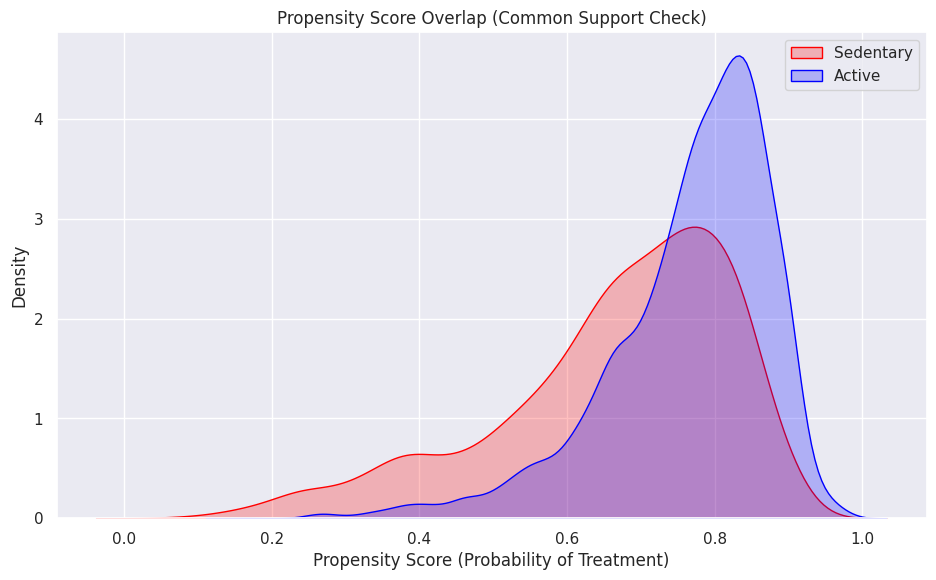

INFO:utils:--- Diagnostic Interpretation ---
INFO:utils:Good Overlap: The red and blue distributions share the same x-axis range
INFO:utils:Bad Overlap: One group is clustered at 0 and the other at 1 (Positivity Violation)


In [16]:
# Check if there is "Common Support" between the treated and control groups.
navigator.check_overlap(X_demo, T_demo)

### `fit_estimate(X, T, Y)`

**Purpose**: Trains the meta-learner and estimates CATE (Conditional Average
Treatment Effect).

- **Inputs**: Covariates `X`, Treatment `T`, Outcome `Y`
- **Output**: `numpy.array` of CATE values - one per observation
- **Design choice**: XGBoost is used as the base learner because it handles
  non-linearities in the response surface effectively, which is crucial for
  the X-Learner

In [17]:
# Estimate effects.
cate_estimates = navigator.fit_estimate(X_demo, T_demo, Y_demo)
print(f"\nAverage Treatment Effect (ATE): {cate_estimates.mean():.4f}")

INFO:utils:Mapping labels: 0.0 -> Sedentary, 1.0 -> Active
INFO:utils:Training X-Learner with XGBoost base models
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:Error metrics for group Active
INFO:causalml:    RMSE   (Control):     0.3144
INFO:causalml:    RMSE (Treatment):     0.2831
INFO:causalml:   sMAPE   (Control):     1.7021
INFO:causalml:   sMAPE (Treatment):     1.8694
INFO:causalml:    Gini   (Control):     0.8328
INFO:causalml:    Gini (Treatment):     0.7536
INFO:utils:Done. Estimated Average Treatment Effect (ATE): -0.0152



Average Treatment Effect (ATE): -0.0152


### `get_cate_df(df_original)`

**Purpose**: Helper to merge the estimated effects back into the original
dataframe.

- **Inputs**: Original dataframe
- **Output**: Dataframe with a new `cate` column

### `plot_heterogeneity(df_with_cate, col, bins=5)`

**Purpose**: Visualises how the treatment effect varies across a specific
feature.

- **Inputs**: Dataframe with CATE, column name, optional bins
- **Output**: A bar chart showing CATE by group with confidence intervals

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


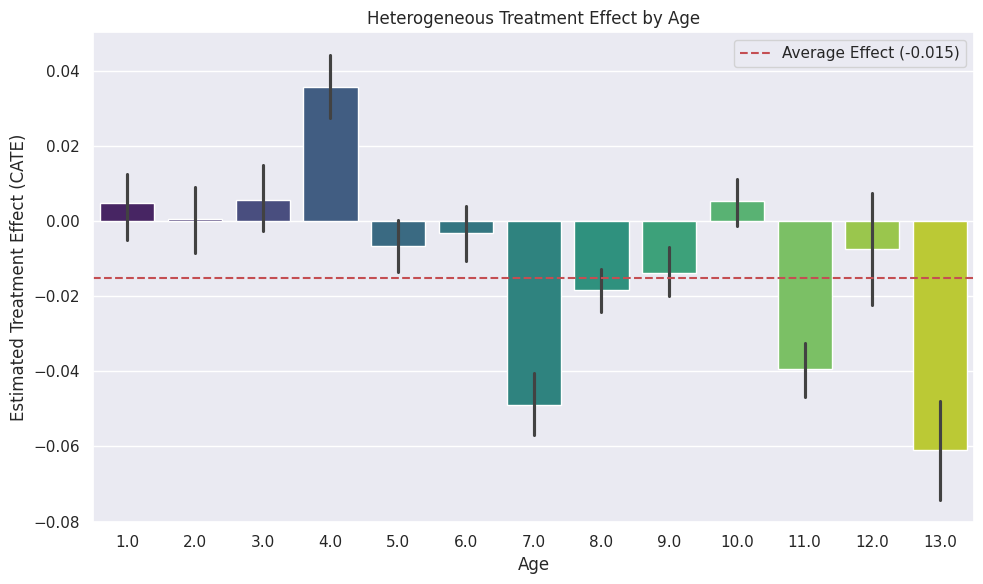

In [18]:
# Visualize results.
df_results = navigator.get_cate_df(X_demo)
navigator.plot_heterogeneity(df_results, col="Age")

### `run_placebo_test(X, T, Y, n_simulations=10)`

**Purpose**: Robustness check (Refutation).

- **Logic**: Randomly shuffles the treatment array to break any true causal
  link, then re-trains the model
- **Success criteria**: The "Placebo ATE" should cluster around 0; the
  "Actual ATE" should be far outside this distribution
- **Interpretation**: If the actual effect falls *inside* the placebo
  distribution, the result is statistically indistinguishable from noise

INFO:utils:Running Placebo Test (3 permutations)
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:Error metrics for group Active
INFO:causalml:    RMSE   (Control):     0.2732
INFO:causalml:    RMSE (Treatment):     0.3013
INFO:causalml:   sMAPE   (Control):     1.7878
INFO:causalml:   sMAPE (Treatment):     1.8411
INFO:causalml:    Gini   (Control):     0.8686
INFO:causalml:    Gini (Treatment):     0.7417
INFO:utils:   Sim 1/3: Placebo ATE = -0.01002
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:Error metrics for group Active
INFO:causalml:    RMSE   (Control):     0.2691
INFO:causalml:    RMSE (Treatment):     0.3031
INFO:causalml:   sMAPE   (Control):     1.8172
INFO:causalml:   sMAPE (Treatment):     1.8316
INFO:causalml:    Gini   (Control):     0.8492
INFO:causalml:    Gini (Treatment):     0.7525
INFO:utils:   Sim 2/3: Placebo ATE = 

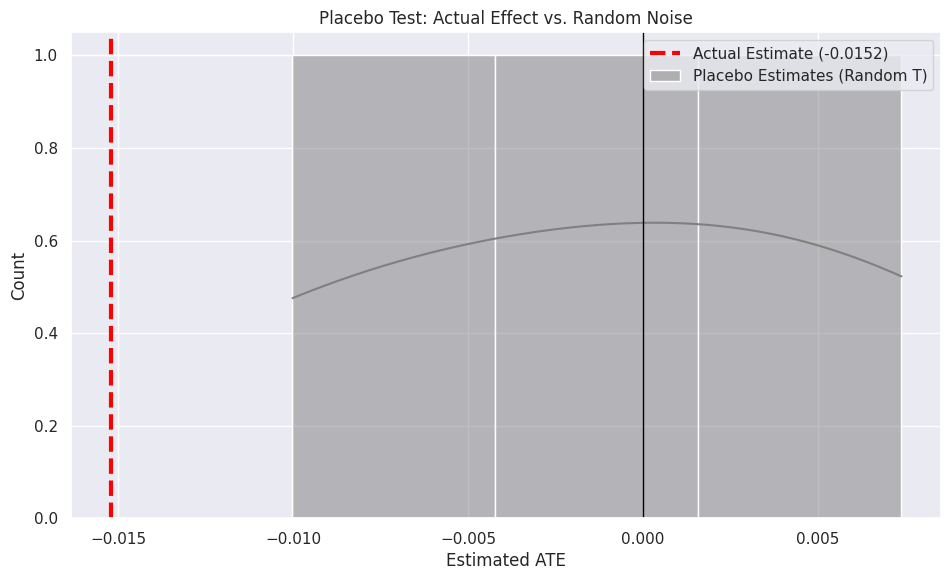

In [19]:
# Robustness check: shuffle T to see if the model finds an effect where none
# exists.
navigator.run_placebo_test(X_demo, T_demo, Y_demo, n_simulations=3)

### `run_sensitivity_analysis(X, T, Y)`

**Purpose**: Quantifies the stability of the causal estimate.

- **Logic**: Iteratively removes one covariate at a time and re-calculates
  the Average Treatment Effect (ATE)
- **Output**: A horizontal bar chart showing the ATE for each scenario
  compared to the baseline
- **Interpretation**:
  - **Stable** - bars cluster near the baseline (red line)
  - **Sensitive** - a bar shifts significantly or crosses zero, indicating
    that specific variable drives the result

INFO:utils:Running Sensitivity Analysis (Covariate Removal)
INFO:utils:   Baseline ATE: -0.01522
INFO:utils:   ... testing robustness without 'HighBP'
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:Error metrics for group Active
INFO:causalml:    RMSE   (Control):     0.3189
INFO:causalml:    RMSE (Treatment):     0.2862
INFO:causalml:   sMAPE   (Control):     1.7075
INFO:causalml:   sMAPE (Treatment):     1.8727
INFO:causalml:    Gini   (Control):     0.8155
INFO:causalml:    Gini (Treatment):     0.7379
INFO:utils:   ... testing robustness without 'HighChol'
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:Error metrics for group Active
INFO:causalml:    RMSE   (Control):     0.3215
INFO:causalml:    RMSE (Treatment):     0.2850
INFO:causalml:   sMAPE   (Control):     1.7096
INFO:causalml:   sMAPE (Treatment):     1.8709
INFO:causalml:    G

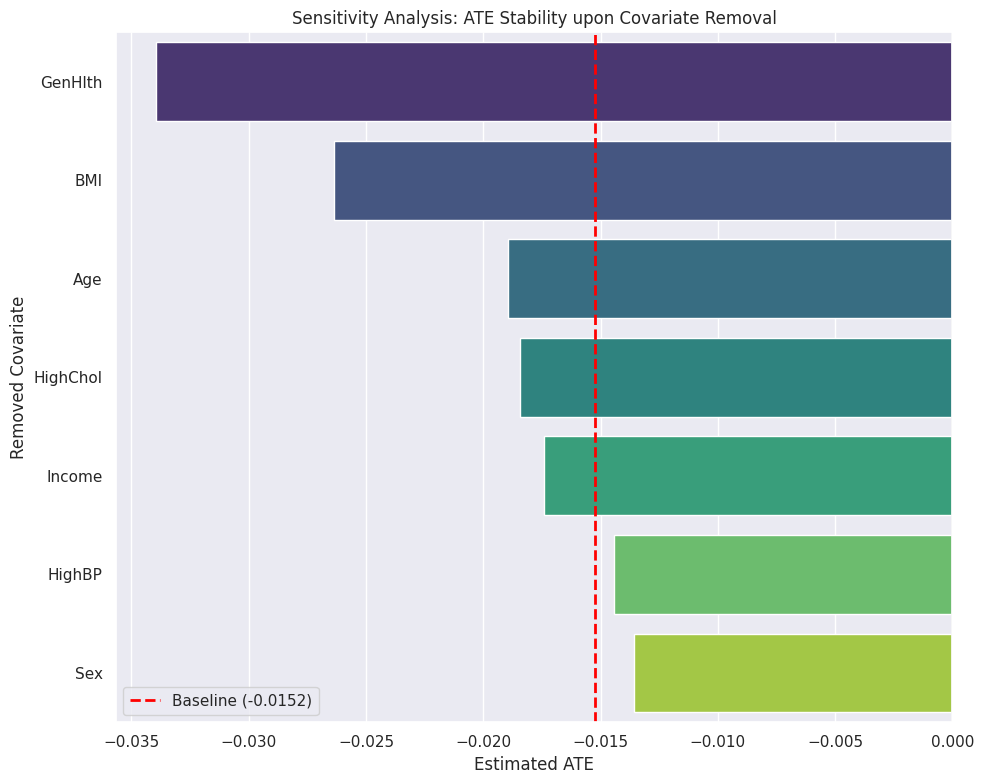

INFO:utils:Interpretation: Variables causing large shifts from the red line are critical confounders


In [20]:
# Sensitivity analysis: check how stable the result is when removing one
# covariate at a time.
navigator.run_sensitivity_analysis(X_demo, T_demo, Y_demo)

### `compare_estimators(X, T, Y)`

**Purpose**: Advanced model selection ("Horse Race").

- **Methodology**: Splits data into Train (70%) and Test (30%); trains S, T,
  X, R, and DR learners on the training set
- **Metric**: Generates a **Cumulative Gain Chart (Uplift Curve)** on the
  test set
- **Why this metric**: Since ground-truth CATE is impossible to observe, RMSE
  cannot be used. The Gain Chart measures how well a model sorts individuals
  from "High Responder" to "Low Responder"
- **Outputs**:
  - **Uplift Curve Plot** - visual comparison of model performance
  - **Qini/AUUC Score Table** - numerical ranking of models (Area Under
    Uplift Curve)

INFO:utils:Starting Estimator Tournament
INFO:utils:Training S-Learner
INFO:utils:Training T-Learner
INFO:utils:Training X-Learner
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:Generating propensity score
INFO:utils:Training R-Learner
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for 1.0 with R-loss
INFO:utils:Training DR-Learner
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:Generate outcome regressions
INFO:causalml:Fit pseudo outcomes from the DR formula
INFO:causalml:Generating propensity score
INFO:causalml:predict_proba not available, using predict instead
INFO:causalml:Generate outcome regressions
INFO:causalml:Fit pseudo outcomes from the DR formula
INFO:causalml:Ge

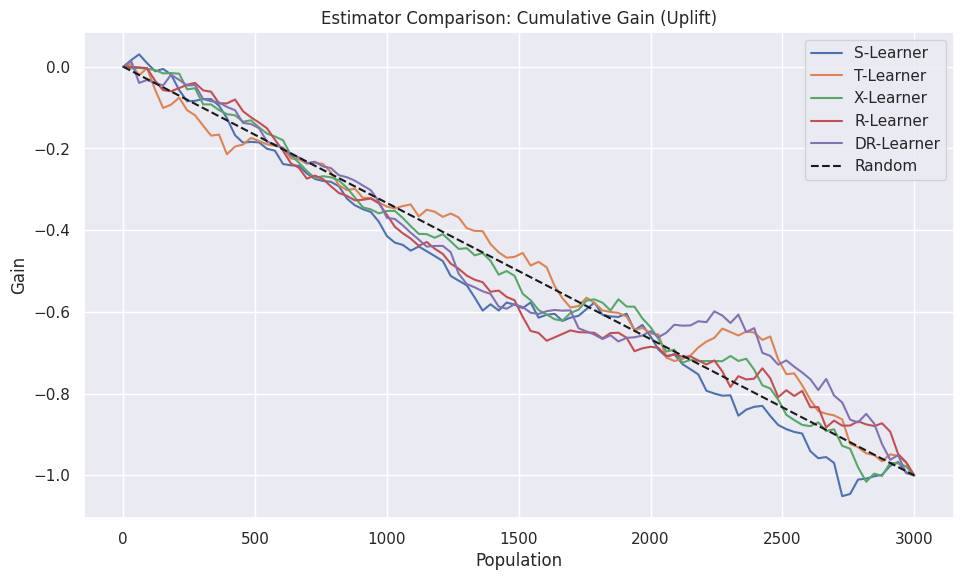

INFO:utils:Interpretation: The line that stays highest on the Y-axis sorts patients best


In [21]:
# Estimator comparison ("Horse Race"): compare X-Learner against S, T, R, and
# DR Learners using Uplift Curves.
navigator.compare_estimators(X_demo, T_demo, Y_demo)